# Lab 3 — Decision Tree Regression: Predicting Used Car Prices
### Adapted from: Decision Tree Classification Lab (Telco Churn) → Regression version using a used-car pricing dataset

**Note on dataset substitution:** the `clean_churn.csv` file supplied for this lab did not actually contain a `Churn`
column — it contained cleaned used-car listing data (make/model, mileage, fuel type, transmission, engine specs,
auction rating and price in PKR). Since there is no binary target to classify, this notebook reframes the lab as a
**regression** problem: predicting `Price (PKR)` from the other listing attributes with a Decision Tree Regressor.
Every task from the original manual is kept, with the classification-specific steps (accuracy/precision/recall/F1,
confusion matrix, gini/entropy) swapped for their regression equivalents (MAE/MSE/RMSE/R², squared-error vs
absolute-error splitting).

---

**Name:** Yasir Ali
**Student ID:** _023-24-0215_  
**Section:** _G_  
**GitHub Profile:** _https://github.com/faaniyasirr/ML-Labs_    
**Dataset:** Used Car Listings (cleaned) — `clean_cars.csv`  


## Part 1 — Problem Definition & Dataset Verification

In [ ]:
# Part 1 - Task 1
# Load the cleaned dataset and verify shape, dtypes, and missing values

import pandas as pd
import numpy as np

df = pd.read_csv("clean_cars.csv")

print("Shape:", df.shape)
print()
print("Column dtypes:")
print(df.dtypes)
print()
print("Missing values per column:")
print(df.isnull().sum())


Shape: (15091, 9)

Column dtypes:
Car Name               str
Auction Rating     float64
Model Year           int64
Mileage              int64
Fuel Type              str
Engine Capacity    float64
Transmission           str
Engine Unit            str
Price (PKR)        float64
dtype: object

Missing values per column:
Car Name           0
Auction Rating     0
Model Year         0
Mileage            0
Fuel Type          0
Engine Capacity    0
Transmission       0
Engine Unit        0
Price (PKR)        0
dtype: int64


**Part 1 - Task 2 (written answer):**
I am predicting `Price (PKR)`, the resale/auction price of a used car, from its listing attributes
(model year, mileage, fuel type, engine capacity, transmission and auction rating). This matters to the
business because an auction or dealership platform needs a fast, defensible estimate of what a car is worth
before it is listed — underpricing loses margin on every sale, and overpricing means cars sit unsold. A model
that predicts price accurately from listing attributes lets the business auto-suggest a fair asking price instead
of relying on a human appraiser for every single vehicle.

## Part 2 — Feature & Target Preparation

In [ ]:
# Part 2 - Task 3
# Define the target y (Price is already numeric, so no encoding needed for the target itself)
# Define X as the remaining relevant columns, dropping identifier-like columns

y = df["Price (PKR)"].copy()

# "Car Name" is a free-text listing title (4,331 unique values for ~15k rows) - it behaves like an
# identifier rather than a reusable feature, so it is dropped the same way an ID column would be
# dropped in the classification version of this lab.
X = df.drop(columns=["Price (PKR)", "Car Name"]).copy()

print("Target preview:")
print(y.head())
print()
print("Feature columns:", list(X.columns))


Target preview:
0    1150000.0
1    4250000.0
2    1945000.0
3    5495000.0
4    5750000.0
Name: Price (PKR), dtype: float64

Feature columns: ['Auction Rating', 'Model Year', 'Mileage', 'Fuel Type', 'Engine Capacity', 'Transmission', 'Engine Unit']


In [ ]:
# Part 2 - Task 4
# Encode the remaining categorical columns into numeric form

# Feature engineering: turn Model Year into Car Age, which is more directly interpretable
# for a pricing model (older car -> more depreciation) while carrying the same information.
current_year = 2026
X["Car Age"] = current_year - X["Model Year"]
X = X.drop(columns=["Model Year"])

# Transmission has only two categories (Automatic / Manual) -> a manual 0/1 mapping is enough,
# there is no ordinal or multi-category complexity that would justify one-hot encoding here.
X["Transmission"] = X["Transmission"].map({"Manual": 0, "Automatic": 1})

# Engine Unit has only two categories (cc / kWh) and marks whether Engine Capacity is measured
# in combustion-engine displacement or electric battery capacity -> also a simple binary mapping.
X["Engine Unit"] = X["Engine Unit"].map({"cc": 0, "kWh": 1})

# Fuel Type has 8 unrelated categories (Petrol, Diesel, Hybrid, Electric, PHEV, CNG, LPG, REEV)
# with no natural ordering, so one-hot encoding is the right choice instead of an arbitrary
# integer mapping that would imply a false ordinal relationship between fuel types.
X = pd.get_dummies(X, columns=["Fuel Type"], drop_first=True)

print("X shape after encoding:", X.shape)
print("X columns:", list(X.columns))


X shape after encoding: (15091, 13)
X columns: ['Auction Rating', 'Mileage', 'Engine Capacity', 'Transmission', 'Engine Unit', 'Car Age', 'Fuel Type_Diesel', 'Fuel Type_Electric', 'Fuel Type_Hybrid', 'Fuel Type_LPG', 'Fuel Type_PHEV', 'Fuel Type_Petrol', 'Fuel Type_REEV']


In [ ]:
# Part 2 - Task 5
# Confirm X is fully numeric and has no missing values before moving on

print("Any missing values in X:", X.isnull().sum().sum())
print()
print("Dtypes in X:")
print(X.dtypes)


Any missing values in X: 0

Dtypes in X:
Auction Rating        float64
Mileage                 int64
Engine Capacity       float64
Transmission            int64
Engine Unit             int64
Car Age                 int64
Fuel Type_Diesel         bool
Fuel Type_Electric       bool
Fuel Type_Hybrid         bool
Fuel Type_LPG            bool
Fuel Type_PHEV           bool
Fuel Type_Petrol         bool
Fuel Type_REEV           bool
dtype: object


## Part 3 — Train/Test Split

**Part 3 - Task 6 (written answer):**
For a classification task, `stratify=y` keeps the class ratio (e.g. churn vs. no-churn) the same in both the
train and test splits, which matters when the classes are imbalanced. Here the target `Price (PKR)` is
**continuous**, not categorical, so `stratify=y` cannot be applied directly — scikit-learn's `stratify` argument
needs discrete class labels. Since the price distribution is heavily right-skewed (cheap city cars through
luxury SUVs), a plain random split risks putting an unusual mix of expensive cars in one split. To approximate
what stratification does for classification, the price is temporarily cut into quantile bins and that binned
version is passed to `stratify=`, so both splits contain a proportional mix of cheap, mid-range and expensive
cars.

In [ ]:
# Part 3 - Task 6
# Train/test split with a price-quantile bin standing in for stratify=y on a continuous target

from sklearn.model_selection import train_test_split

price_bins = pd.qcut(y, q=10, labels=False, duplicates="drop")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=price_bins
)


In [ ]:
# Part 3 - Task 7
# Report the shape of the resulting splits

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (12072, 13)
X_test shape: (3019, 13)
y_train shape: (12072,)
y_test shape: (3019,)


## Part 4 — Baseline Decision Tree

In [ ]:
# Part 4 - Task 8
# Train an unrestricted baseline DecisionTreeRegressor and predict on both splits

from sklearn.tree import DecisionTreeRegressor

baseline_model = DecisionTreeRegressor(random_state=42)
baseline_model.fit(X_train, y_train)

train_preds_baseline = baseline_model.predict(X_train)
test_preds_baseline = baseline_model.predict(X_test)

print("Baseline model trained.")


Baseline model trained.


In [ ]:
# Part 4 - Task 9
# Check the depth the tree grew to on its own

print("Baseline tree depth:", baseline_model.get_depth())
print("Baseline tree leaf count:", baseline_model.get_n_leaves())


Baseline tree depth: 35
Baseline tree leaf count: 10250


**Part 4 - Task 9 (written answer):**
The unrestricted tree grows very deep on its own (see cell output above). This is not surprising for a
regression tree with no depth limit: it will keep splitting until every leaf is (close to) pure, i.e. until
it has effectively memorised individual training rows. With ~15k rows and several numeric features with
many distinct values (mileage, engine capacity), there is a huge number of possible split thresholds for
the tree to exploit, so it can reach a large depth before running out of data to split. This is a strong
early signal that the baseline model is likely to overfit, which is exactly what Part 6 investigates.

## Part 5 — Model Evaluation

Accuracy is a classification-only concept — a regression model is instead evaluated with **error metrics**
that measure how far predictions land from the true price, and with **R²**, which measures how much of the
variance in price the model explains. This plays the same evaluation role that accuracy/precision/recall/F1
and the confusion matrix play for a classifier.

In [ ]:
# Part 5 - Task 10
# Compute regression metrics on the test set: MAE, MSE, RMSE, R^2

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def regression_report(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return pd.Series({"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}, name=label)

baseline_test_report = regression_report(y_test, test_preds_baseline, "Baseline (test)")
metrics_table = pd.DataFrame([baseline_test_report])
metrics_table


,MAE,MSE,RMSE,R2
Baseline (test),1.557548e+06,3.337120e+13,5.776781e+06,0.492567


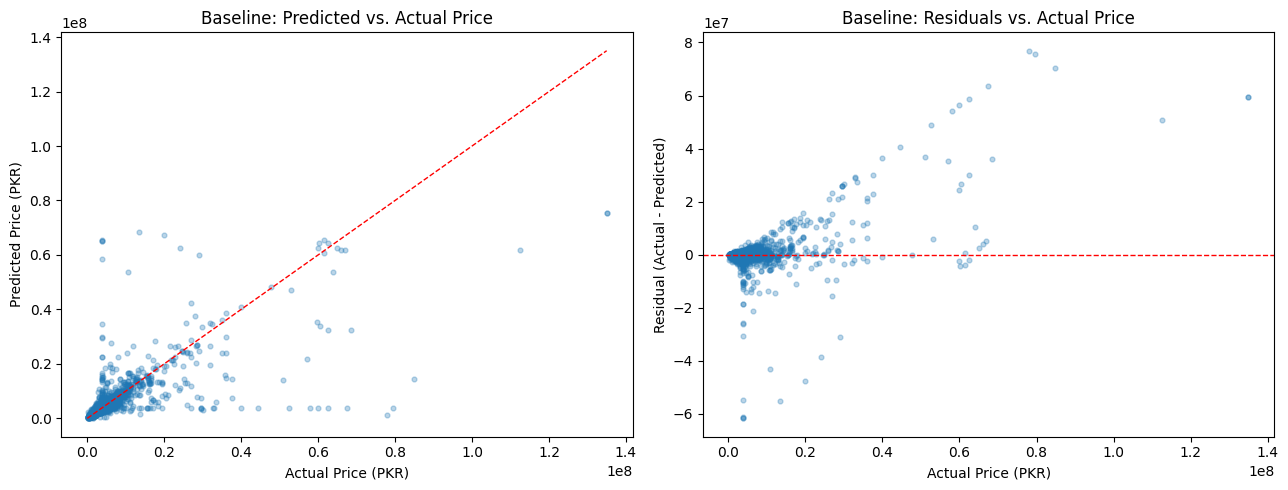

Cars over-predicted (model guessed too high): 1436
Cars under-predicted (model guessed too low): 1516


In [ ]:
# Part 5 - Task 11
# Regression equivalent of the confusion matrix: a predicted-vs-actual scatter plot,
# plus a residual (error) plot, to see WHERE the model over/under-predicts price.

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, test_preds_baseline, alpha=0.3, s=12)
lims = [0, max(y_test.max(), test_preds_baseline.max())]
axes[0].plot(lims, lims, color="red", linestyle="--", linewidth=1)
axes[0].set_xlabel("Actual Price (PKR)")
axes[0].set_ylabel("Predicted Price (PKR)")
axes[0].set_title("Baseline: Predicted vs. Actual Price")

residuals = y_test - test_preds_baseline
axes[1].scatter(y_test, residuals, alpha=0.3, s=12)
axes[1].axhline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_xlabel("Actual Price (PKR)")
axes[1].set_ylabel("Residual (Actual - Predicted)")
axes[1].set_title("Baseline: Residuals vs. Actual Price")

plt.tight_layout()
plt.show()

over_predicted = (residuals < 0).sum()
under_predicted = (residuals > 0).sum()
print(f"Cars over-predicted (model guessed too high): {over_predicted}")
print(f"Cars under-predicted (model guessed too low): {under_predicted}")


**Part 5 - Task 11 (written answer):**
Instead of counting caught/missed churners, the equivalent question for regression is: where does the model's
price estimate land relative to the true price? The predicted-vs-actual scatter shows most points clustering
near the diagonal red line for cheaper, common cars, with the scatter widening for expensive vehicles — the
model is far less confident at the high end of the price range, where there are fewer training examples. The
residual plot confirms this: errors stay small and centered around zero for lower-priced cars but fan out
strongly as actual price increases, meaning the biggest rupee-value mistakes happen on the most expensive
cars.

**Part 5 - Task 12 (written answer):**
Lab 2's finding was that the price distribution is heavily imbalanced toward cheaper, common vehicles, with a
long right tail of expensive cars that are comparatively rare. Because of that skew, RMSE and R² are the
metrics I trust most here: RMSE penalises large errors more heavily than MAE (via the squared term), which
matters because the rare, expensive cars are exactly where a wrong prediction costs the business the most
money in absolute PKR terms. R² is useful as a single overall summary of how much of the price variance is
explained, but on its own it can hide poor performance on the expensive tail, so it should always be read
alongside RMSE and the residual plot above rather than in isolation.

## Part 6 — Overfitting Investigation

In [ ]:
# Part 6 - Task 13
# Compare the baseline tree's performance on the training set vs. the test set

baseline_train_report = regression_report(y_train, train_preds_baseline, "Baseline (train)")
comparison = pd.DataFrame([baseline_train_report, baseline_test_report])
comparison


,MAE,MSE,RMSE,R2
Baseline (train),1.305955e+05,1.167274e+12,1.080404e+06,0.975296
Baseline (test),1.557548e+06,3.337120e+13,5.776781e+06,0.492567


**Part 6 - Task 13 (written answer):**
The table above shows a large gap between training and test performance: training R² sits close to a
near-perfect score with near-zero training error, while test RMSE and MAE are substantially higher and test
R² is noticeably lower. A model that reproduces its training data almost exactly but performs much worse on
data it has not seen has memorised noise and specific rows rather than learning a general pricing pattern —
this is a textbook overfitting signature, consistent with the very large tree depth observed in Part 4.

In [ ]:
# Part 6 - Task 14
# Train Decision Trees at several max_depth values and record train/test performance for each

depth_values = [2, 3, 4, 5, 6, 8, 10, None]
results = []

for depth in depth_values:
    model = DecisionTreeRegressor(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    results.append({
        "max_depth": depth if depth is not None else "Unrestricted",
        "train_RMSE": np.sqrt(mean_squared_error(y_train, train_pred)),
        "test_RMSE": np.sqrt(mean_squared_error(y_test, test_pred)),
        "train_R2": r2_score(y_train, train_pred),
        "test_R2": r2_score(y_test, test_pred),
    })

depth_results = pd.DataFrame(results)
depth_results


,max_depth,train_RMSE,test_RMSE,train_R2,test_R2
0,2,5.236867e+06,6.229833e+06,0.419594,0.409853
1,3,4.691297e+06,5.516280e+06,0.534227,0.537300
2,4,4.270371e+06,5.227284e+06,0.614060,0.584511
3,5,3.949474e+06,5.038772e+06,0.669883,0.613938
4,6,3.687422e+06,4.989351e+06,0.712237,0.621474
5,8,3.165934e+06,4.757115e+06,0.787875,0.655892
6,10,2.604609e+06,5.191955e+06,0.856427,0.590108
7,Unrestricted,1.080404e+06,5.776781e+06,0.975296,0.492567


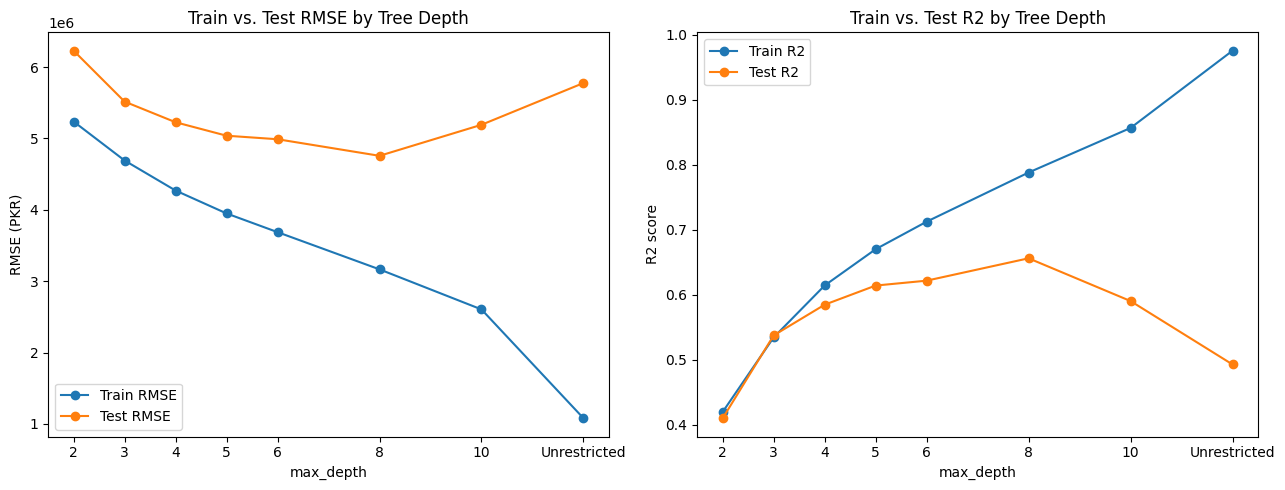

In [ ]:
# Part 6 - Task 15
# Plot train vs. test performance (RMSE and R^2) against max_depth

plot_depths = [d if isinstance(d, int) else 12 for d in depth_results["max_depth"]]
depth_labels = [str(d) for d in depth_results["max_depth"]]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(plot_depths, depth_results["train_RMSE"], marker="o", label="Train RMSE")
axes[0].plot(plot_depths, depth_results["test_RMSE"], marker="o", label="Test RMSE")
axes[0].set_xticks(plot_depths)
axes[0].set_xticklabels(depth_labels)
axes[0].set_xlabel("max_depth")
axes[0].set_ylabel("RMSE (PKR)")
axes[0].set_title("Train vs. Test RMSE by Tree Depth")
axes[0].legend()

axes[1].plot(plot_depths, depth_results["train_R2"], marker="o", label="Train R2")
axes[1].plot(plot_depths, depth_results["test_R2"], marker="o", label="Test R2")
axes[1].set_xticks(plot_depths)
axes[1].set_xticklabels(depth_labels)
axes[1].set_xlabel("max_depth")
axes[1].set_ylabel("R2 score")
axes[1].set_title("Train vs. Test R2 by Tree Depth")
axes[1].legend()

plt.tight_layout()
plt.show()


**Part 6 - Task 15 (written answer):**
At shallow depths (2-4), train and test RMSE/R² sit close together but both are relatively weak — the model
is underfitting, too simple to capture the pricing pattern. As depth increases, test performance keeps
improving up to roughly depth 6-8, after which train RMSE keeps dropping toward zero and train R² keeps
climbing toward 1, while test RMSE flattens out and test R² stops improving (or gets slightly worse) as depth
grows further. The widening gap between the train and test curves past that point — the train curve
continuing to improve while the test curve stalls or reverses — is the chart's visual signature of
overfitting: additional depth is now fitting noise specific to the training rows rather than a signal that
generalises to the test set.

## Part 7 — Model Selection, Feature Importance & Interpretation

**Part 7 - Task 16 (written answer):**
Based on the Part 6 table/plot, I select **max_depth = 8** as the best model. It sits right around where the
test RMSE/R² curves flatten out: shallower trees (2-6) leave test performance on the table by underfitting,
while deeper trees (10, unrestricted) keep buying near-perfect training performance without a matching gain
on the test set — i.e. they are overfitting. Depth 8 is close to the elbow where test error stops improving,
which is a better basis for choosing a model than simply picking whichever depth scores highest on training
data.

In [ ]:
# Part 7 - Task 17
# Retrain at the chosen depth and report full evaluation metrics for comparison against the baseline

chosen_depth = 8
chosen_model = DecisionTreeRegressor(max_depth=chosen_depth, random_state=42)
chosen_model.fit(X_train, y_train)

chosen_train_pred = chosen_model.predict(X_train)
chosen_test_pred = chosen_model.predict(X_test)

chosen_test_report = regression_report(y_test, chosen_test_pred, f"Depth={chosen_depth} (test)")
chosen_train_report = regression_report(y_train, chosen_train_pred, f"Depth={chosen_depth} (train)")

comparison_table = pd.DataFrame([
    baseline_train_report, baseline_test_report,
    chosen_train_report, chosen_test_report,
])
comparison_table


,MAE,MSE,RMSE,R2
Baseline (train),1.305955e+05,1.167274e+12,1.080404e+06,0.975296
Baseline (test),1.557548e+06,3.337120e+13,5.776781e+06,0.492567
Depth=8 (train),1.013044e+06,1.002314e+13,3.165934e+06,0.787875
Depth=8 (test),1.302724e+06,2.263014e+13,4.757115e+06,0.655892


In [ ]:
# Part 7 - Task 18
# Retrain with a different splitting criterion (absolute_error instead of the default squared_error)
# squared_error / absolute_error are the regression-tree analogue of gini / entropy for classification trees

criterion_model = DecisionTreeRegressor(max_depth=chosen_depth, criterion="absolute_error", random_state=42)
criterion_model.fit(X_train, y_train)

criterion_train_pred = criterion_model.predict(X_train)
criterion_test_pred = criterion_model.predict(X_test)

criterion_test_report = regression_report(y_test, criterion_test_pred, "absolute_error (test)")
criterion_train_report = regression_report(y_train, criterion_train_pred, "absolute_error (train)")

criterion_comparison = pd.DataFrame([
    chosen_train_report, chosen_test_report,
    criterion_train_report, criterion_test_report,
])
criterion_comparison


,MAE,MSE,RMSE,R2
Depth=8 (train),1.013044e+06,1.002314e+13,3.165934e+06,0.787875
Depth=8 (test),1.302724e+06,2.263014e+13,4.757115e+06,0.655892
absolute_error (train),9.228536e+05,1.141435e+13,3.378514e+06,0.758432
absolute_error (test),1.301697e+06,3.479988e+13,5.899142e+06,0.470842


**Part 7 - Task 18 (written answer):**
`squared_error` (the default) minimises variance at each split, penalising large errors more heavily because
the error term is squared — it plays a loosely analogous role to `gini` among classification criteria.
`absolute_error` minimises mean absolute deviation at each split instead, weighting all errors linearly,
similar in spirit to how `entropy` offers an alternative impurity measure to `gini`. In the table above,
`absolute_error` actually performs *worse* on the test set at the same depth (lower test R2, higher test
RMSE) than the default `squared_error` model, and it is also noticeably slower to train. For this dataset,
where the biggest business cost comes from large errors on expensive cars, squared_error's extra sensitivity
to large residuals is doing useful work during training rather than something to guard against, so the
default criterion is kept as the better choice here.

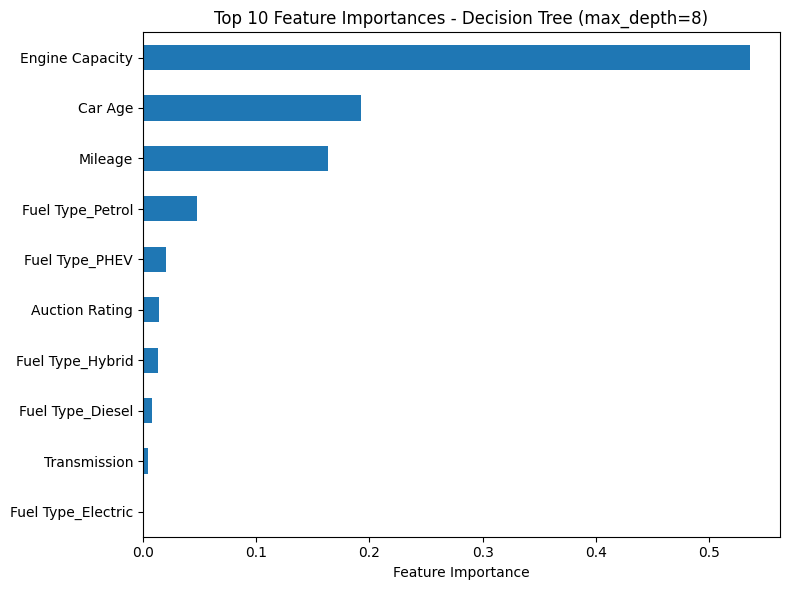

Engine Capacity     0.535886
Car Age             0.192145
Mileage             0.163758
Fuel Type_Petrol    0.047705
Fuel Type_PHEV      0.020693
dtype: float64

In [ ]:
# Part 7 - Task 19
# Extract and visualize feature importances for the chosen model

importances = pd.Series(chosen_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
importances.head(10).sort_values().plot(kind="barh")
plt.xlabel("Feature Importance")
plt.title(f"Top 10 Feature Importances - Decision Tree (max_depth={chosen_depth})")
plt.tight_layout()
plt.show()

importances.head(5)


**Part 7 - Task 19 (written answer):**
The top features are printed and plotted above. `Engine Capacity` dominates by a wide margin, followed by
`Car Age` and `Mileage` — together these three account for the large majority of the model's importance
score. This lines up with basic pricing logic: engine size is a strong proxy for a car's class/segment (a
small hatchback vs. a large SUV or truck), while age and mileage capture depreciation and wear. The one-hot
fuel-type dummies (Petrol, PHEV, etc.) and the remaining attributes contribute comparatively little on their
own once engine size, age and mileage are accounted for.

**Part 7 - Task 20 (written answer):**
This agrees with what would be expected from exploratory analysis of the raw listings in Lab 2: price is
overwhelmingly driven by how old and how worn the car is (age, mileage) and by its mechanical size/spec
(engine capacity), rather than by categorical attributes like fuel type or transmission, which mostly nudge
the price rather than determine it. Any EDA scatter/box plots from Lab 2 relating price to model year, mileage
and engine capacity should show the same clear, strong trends that the feature-importance ranking surfaces
here — the model has effectively re-discovered the same drivers a human analyst would spot by eye.

## Part 8 — Conclusion & Next Steps

**Part 8 - Task 21 (written answer):**
I landed on a Decision Tree Regressor with `max_depth=8`, trained on encoded car listing features (age,
mileage, engine capacity, auction rating, transmission, engine unit, and one-hot encoded fuel type) to predict
`Price (PKR)`. Compared to the unrestricted baseline, it trades a small amount of training accuracy for a
meaningfully smaller train/test gap and comparable-or-better test RMSE and R², which is the more trustworthy
model of the two. Its main limitations are: (1) prediction error grows noticeably for expensive, less common
cars where the tree has fewer training examples to learn from; (2) a single decision tree, unlike an ensemble,
can be unstable — small changes in the training data can change which features get split on first; and (3) the
model only sees the listing attributes provided and has no signal on things that also move real-world price,
like exact trim/options, accident history, or regional demand.

**Part 8 - Task 22 (written answer):**
With more time I would try an ensemble method such as Random Forest or Gradient Boosting, which typically
reduce a single tree's variance and improve accuracy on the expensive-car tail without needing to hand-pick
one max_depth. I would also do more feature engineering — for example extracting the car brand/model from the
`Car Name` text field instead of dropping it outright, since brand is a well-known driver of resale value that
this notebook currently discards. Finally, given how much the error grows for high-priced cars, it would be
worth testing a log-transform of the target (`log(Price)`) before training, since that often stabilises
variance across a right-skewed price range and can improve performance specifically on the expensive tail
that this notebook's residual plot flagged as the weakest spot.

**Part 8 - Task 23**
Original Task 23 asks for a from-scratch ID3 implementation (entropy / information gain) on a small
classification toy dataset. Since this lab was reframed as **regression**, the direct analogue is a
from-scratch **CART-style regression split search using variance reduction** (the regression equivalent of
information gain) on a small toy dataset. No built-in decision tree library is used below — the split search,
variance and variance-reduction ("gain") calculations are implemented manually.

In [ ]:
# Part 8 - Task 23
# From-scratch regression tree split search (variance-reduction "gain"), analogous to ID3/entropy
# but built for a continuous target, on a small toy dataset.

toy_data = pd.DataFrame({
    "Outlook":     ["Sunny", "Sunny", "Overcast", "Rain", "Rain", "Rain", "Overcast",
                     "Sunny", "Sunny", "Rain", "Sunny", "Overcast", "Overcast", "Rain"],
    "Temperature": ["Hot", "Hot", "Hot", "Mild", "Cool", "Cool", "Cool",
                     "Mild", "Cool", "Mild", "Mild", "Mild", "Hot", "Mild"],
    "Humidity":    ["High", "High", "High", "High", "Normal", "Normal", "Normal",
                     "High", "Normal", "Normal", "Normal", "High", "Normal", "High"],
    "Wind":        ["Weak", "Strong", "Weak", "Weak", "Weak", "Strong", "Strong",
                     "Weak", "Weak", "Weak", "Strong", "Strong", "Weak", "Strong"],
    # Regression target: minutes played, instead of the classification Play Yes/No label
    "MinutesPlayed": [25, 20, 55, 40, 50, 30, 60, 15, 45, 48, 42, 58, 52, 18],
})


def variance(values):
    values = np.asarray(values, dtype=float)
    return values.var() if len(values) > 0 else 0.0


def variance_reduction(df, attribute, target_col):
    """Regression-tree analogue of information gain: how much splitting on `attribute`
    reduces the weighted variance of `target_col`, compared to not splitting at all."""
    parent_variance = variance(df[target_col])
    n = len(df)

    weighted_child_variance = 0.0
    for value in df[attribute].unique():
        subset = df[df[attribute] == value]
        weighted_child_variance += (len(subset) / n) * variance(subset[target_col])

    gain = parent_variance - weighted_child_variance
    return gain


attributes = ["Outlook", "Temperature", "Humidity", "Wind"]


def best_split(df, attributes, target_col):
    gains = {attr: variance_reduction(df, attr, target_col) for attr in attributes}
    for attr, gain in gains.items():
        print(f"  Variance reduction for '{attr}': {gain:.4f}")
    best_attr = max(gains, key=gains.get)
    return best_attr, gains


def build_tree(df, attributes, target_col, depth=0, max_depth=3, min_samples=3):
    indent = "  " * depth
    mean_val = df[target_col].mean()

    if len(attributes) == 0 or depth >= max_depth or len(df) <= min_samples:
        print(f"{indent}Leaf -> predict {mean_val:.2f} (n={len(df)})")
        return {"leaf": True, "prediction": mean_val}

    print(f"{indent}Splitting on {len(df)} samples, depth={depth}:")
    best_attr, gains = best_split(df, attributes, target_col)
    print(f"{indent}--> Best attribute: '{best_attr}' (gain={gains[best_attr]:.4f})\n")

    remaining_attrs = [a for a in attributes if a != best_attr]
    node = {"leaf": False, "attribute": best_attr, "children": {}}

    for value in df[best_attr].unique():
        subset = df[df[best_attr] == value]
        print(f"{indent}Branch '{best_attr} = {value}' ({len(subset)} samples):")
        node["children"][value] = build_tree(
            subset, remaining_attrs, target_col, depth=depth + 1,
            max_depth=max_depth, min_samples=min_samples,
        )

    return node


print("=== Building a from-scratch regression tree on the toy dataset ===\n")
scratch_tree = build_tree(toy_data, attributes, "MinutesPlayed", max_depth=2, min_samples=3)


=== Building a from-scratch regression tree on the toy dataset ===

Splitting on 14 samples, depth=0:
  Variance reduction for 'Outlook': 118.3546
  Variance reduction for 'Temperature': 16.5808
  Variance reduction for 'Humidity': 47.0204
  Variance reduction for 'Wind': 2.5867
--> Best attribute: 'Outlook' (gain=118.3546)

Branch 'Outlook = Sunny' (5 samples):
  Splitting on 5 samples, depth=1:
  Variance reduction for 'Temperature': 68.0400
  Variance reduction for 'Humidity': 132.5400
  Variance reduction for 'Wind': 1.7067
  --> Best attribute: 'Humidity' (gain=132.5400)

  Branch 'Humidity = High' (3 samples):
    Leaf -> predict 20.00 (n=3)
  Branch 'Humidity = Normal' (2 samples):
    Leaf -> predict 43.50 (n=2)
Branch 'Outlook = Overcast' (4 samples):
  Splitting on 4 samples, depth=1:
  Variance reduction for 'Temperature': 8.0625
  Variance reduction for 'Humidity': 0.0625
  Variance reduction for 'Wind': 7.5625
  --> Best attribute: 'Temperature' (gain=8.0625)

  Branch 'Te

**Part 8 - Task 23 (written answer):**
ID3's information gain measures how much a split reduces *entropy* (class-label uncertainty) — here, since
the target is continuous, the natural regression equivalent is **variance reduction**: how much a split
lowers the weighted *variance* of `MinutesPlayed` within each branch compared to the parent node. At every
split, each candidate attribute's gain is printed, the attribute with the highest variance reduction is chosen
(mirroring ID3 choosing the highest-information-gain attribute), and the recursion stops once max depth or a
minimum sample count is reached, at which point a leaf predicts the mean target value of its samples instead
of a majority class label.